**Regenerating Figure 2C: scKTLD TADs Detection**

To reproduce Figure 2C, run the script `2.c_plot_tads` provided in the `tad_detection/` directory of this repository.
To reproduce this figure, first install the [scKTLD package](https://github.com/lhqxinghun/scKTLD) following the instructions provided on the project's GitHub page.
ALso you have to generate band-normalized contact matrices using the BandNorm normalization workflow provided in the BandNorm repository. A normalized contact matrix is used as input for the downstream TAD detection analysis.

Colormaps checked/registered successfully
Loaded edge list shape: (1763, 3)
Converting 1-based to 0-based indices
Min index: 5.0, Max index: 389.0
Converted to adjacency matrix shape: (391, 391)
(391, 391)
neg 0.0005428791046142578
sparsesvd time 0.0240631103515625
Chebyshev expansion
Node embedding done!
Starting TAD boundary detection
TAD boundary detection Done!
(391, 391)
neg 0.0004260540008544922
sparsesvd time 0.026454925537109375
Chebyshev expansion
Node embedding done!
(391, 391)
neg 0.0016169548034667969
sparsesvd time 0.038533926010131836
Chebyshev expansion
Node embedding done!


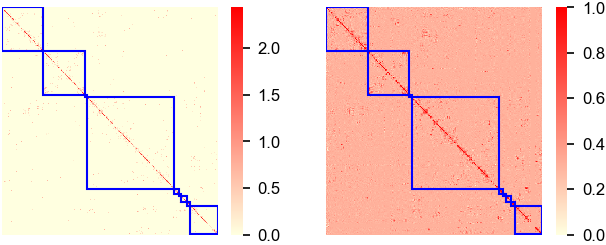

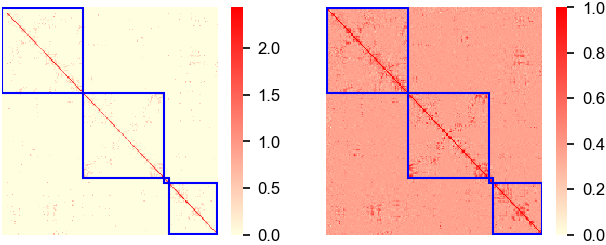

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Oct  6 01:01:23 2025

@author: mozhganoroujlu
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
import sklearn
import os
from scKTLD import edge2adj, callTLD, displayTLD

# Set a macOS-compatible font to avoid findfont warnings
matplotlib.rcParams['font.family'] = 'Arial'

# Pre-check and register colormaps only if not already registered
try:
    if 'hicheat' not in matplotlib.colormaps:
        hiccolors = ["lightyellow", "red"]
        my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('hicheat', hiccolors)
        matplotlib.colormaps.register(my_cmap)
    if 'featureheat' not in matplotlib.colormaps:
        featurecolors = ["blue", "white", "red"]
        my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('featureheat', featurecolors)
        matplotlib.colormaps.register(my_cmap)
    print("Colormaps checked/registered successfully")
except Exception as e:
    print(f"Error registering colormaps: {e}")
    pass

# Path to your edge list file
path_input = "/Users/mozhganoroujlu/Desktop/MOZHGUN/cell_fate/hi_c/codes_figures/folders/normalized_contacts/bandnorm/bandnorm_txt/AAACGAAAGACCGCAA.txt"

# Verify file exists
if not os.path.exists(path_input):
    raise FileNotFoundError(f"File not found: {path_input}. Ensure it's unzipped and check path.")

# Load edge list
try:
    graph_edge = np.loadtxt(path_input, dtype=np.float32)  # float32 to save memory
    print(f"Loaded edge list shape: {graph_edge.shape}")  # Expect (45301, 3)
    if graph_edge.shape[1] != 3:
        raise ValueError("Edge list must have 3 columns (source, target, weight).")
except Exception as e:
    print(f"Error loading file: {e}")
    raise

# Adjust bin indices (convert 1-based to 0-based if needed)
try:
    if graph_edge[:, :2].min() > 0:  # Check if 1-based
        print("Converting 1-based to 0-based indices")
        graph_edge[:, :2] -= 1
    print(f"Min index: {graph_edge[:, :2].min()}, Max index: {graph_edge[:, :2].max()}")
except Exception as e:
    print(f"Error adjusting indices: {e}")
    raise

# Convert edge list to adjacency matrix
try:
    graph_adj = edge2adj(graph_edge, chr='chr1', resolution=500000, reference='mm10')
    print(f"Converted to adjacency matrix shape: {graph_adj.shape}")  # Expect ~391x391
except Exception as e:
    print(f"Error converting to adjacency matrix: {e}")
    raise

# Run scKTLD analysis
try:
    boundary_spec = callTLD(graph_adj)  # Compute boundaries (TADs)
    # Visualize entire chromosome (0 to ~195M bp, 391 bins)
    displayTLD(graph_adj, boundary_spec, start=0, stop=195554896, brecon=True)  # bp
    # Alternative: Visualize segment (8start= start bin, stop= end bin)
    displayTLD(graph_adj, boundary_spec, start=0, stop=200, brecon=True)  # kb
    plt.show()  # Ensure plot displays in Spyder
except Exception as e:
    print(f"Error in scKTLD functions: {e}")
    raise

Update the input path to point to the desired single-cell contact matrix:

In [6]:

path_input = "/path/to/AAACGAAAGACCGCAA.txt"


where the input file is a text-format contact matrix generated during the preprocessing workflow.

You can adjust the genomic region displayed by modifying the `start` and `stop` parameters in the visualization function.

Visualize a region using genomic coordinates (base pairs):


(391, 391)
neg 0.0059261322021484375
sparsesvd time 0.10177993774414062
Chebyshev expansion
Node embedding done!
(391, 391)
neg 0.0015630722045898438
sparsesvd time 0.02657604217529297
Chebyshev expansion
Node embedding done!


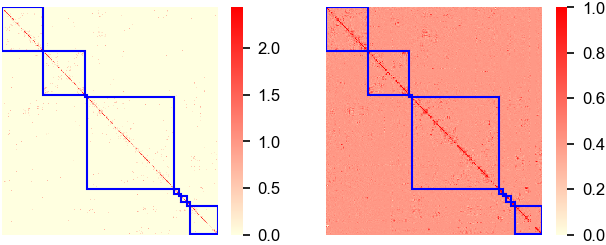

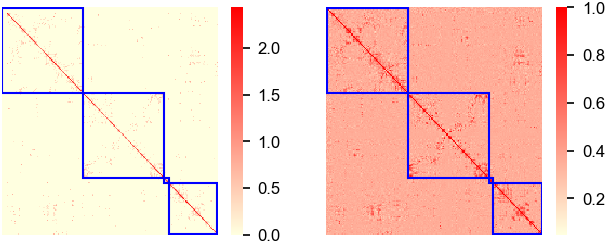

In [9]:

displayTLD(
    graph_adj,
    boundary_spec,
    start=0,
    stop=195554896,
    brecon=True
)


#Alternatively, visualize a region using bin indices:


displayTLD(
    graph_adj,
    boundary_spec,
    start=0,
    stop=200,
    brecon=True
)


In the first example, `start` and `stop` correspond to genomic coordinates in base pairs. In the second example, they correspond to bin indices in the contact matrix. Adjust these values to zoom into specific genomic regions and inspect local TAD structures.